# 이상지질혈증 예측 - XGBoost 베이스 모델

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost Classifier
- 데이터 파일: x1_preprocessed.csv
- 평가지표: Recall (주), F1-score, AUC-ROC

In [3]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
RANDOM_STATE = 42

## 1. 데이터 로드

In [4]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")
print(f"컬럼: {df.columns.tolist()}")

로드 완료 | shape: (6033, 32)
컬럼: ['성별', '나이', '키', '체중', 'BMI', '현재흡연', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '걷기일수', '근력운동일수', '고혈압유병', '당뇨유병', '이상지질혈증유병', '비만단계', '과거음주_현재금주', '음주빈도_enc', '음주량_enc', '직업_관리전문', '직업_기능노무', '직업_농림어업', '직업_무직', '직업_사무', '직업_서비스판매', '직업_작업미상', '직업_주부학생']


## 2. 피처 / 타겟 분리 & 클래스 불균형 확인

In [5]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)

print(f"샘플 수: {len(y)}")
print(f"클래스 분포:\n{y.value_counts()}")
print(f"불균형 비율 (0:1): {y.value_counts()[0]}:{y.value_counts()[1]}")

neg, pos = y.value_counts()[0], y.value_counts()[1]
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight (neg/pos): {scale_pos_weight:.4f}")

샘플 수: 6033
클래스 분포:
이상지질혈증유병
0    4475
1    1558
Name: count, dtype: int64
불균형 비율 (0:1): 4475:1558

scale_pos_weight (neg/pos): 2.8723


## 3. Train / Test 분리

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 양성 비율: {y_train.mean():.3f}")
print(f"Test  양성 비율: {y_test.mean():.3f}")

Train: (4826, 28), Test: (1207, 28)
Train 양성 비율: 0.258
Test  양성 비율: 0.258


## 4. 베이스 모델 학습

In [7]:
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

model.fit(X_train, y_train)
print("학습 완료")

학습 완료


## 5. 평가

In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("=" * 45)
print("  [이상지질혈증 XGBoost 베이스 모델 결과]")
print("=" * 45)
print(f"  Recall   : {recall:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  AUC-ROC  : {auc_roc:.4f}")
print("=" * 45)
print()
print("[분류 리포트]")
print(classification_report(y_test, y_pred, target_names=["정상(0)", "이상지질혈증(1)"]))

  [이상지질혈증 XGBoost 베이스 모델 결과]
  Recall   : 0.6603
  F1-score : 0.5479
  AUC-ROC  : 0.7721

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.86      0.74      0.80       895
   이상지질혈증(1)       0.47      0.66      0.55       312

    accuracy                           0.72      1207
   macro avg       0.66      0.70      0.67      1207
weighted avg       0.76      0.72      0.73      1207



## 6. 혼동 행렬

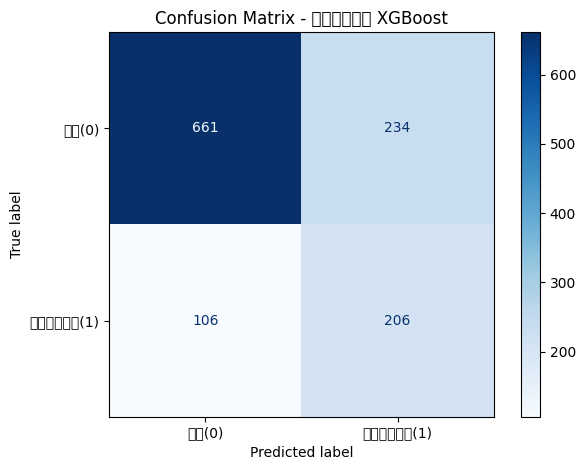

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["정상(0)", "이상지질혈증(1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - 이상지질혈증 XGBoost")
plt.tight_layout()
plt.show()

## 7. ROC 커브

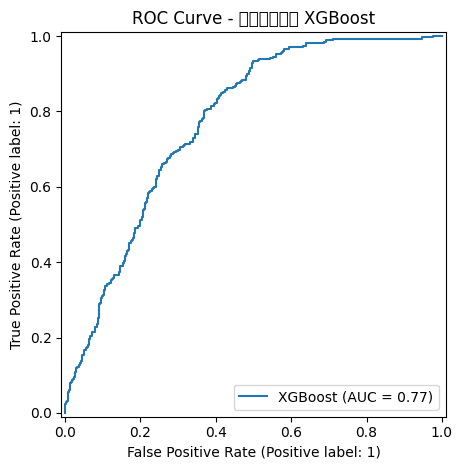

In [10]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba, name="XGBoost")
plt.title("ROC Curve - 이상지질혈증 XGBoost")
plt.tight_layout()
plt.show()

## 8. Feature Importance (Top 20)

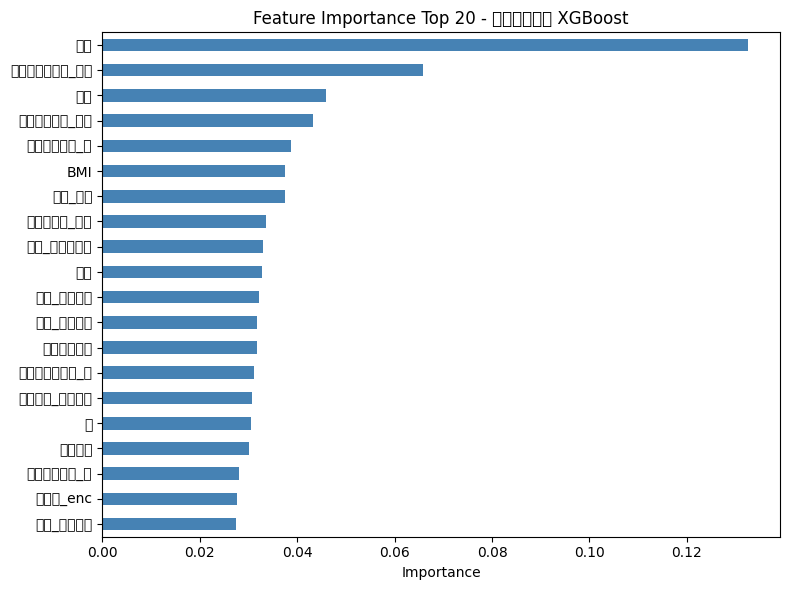

나이            0.132467
고지혈증가족력_형제    0.065933
성별            0.046027
고혈압가족력_형제     0.043259
고혈압가족력_모      0.038730
BMI           0.037600
직업_사무         0.037582
당뇨가족력_형제      0.033714
직업_서비스판매      0.033058
체중            0.032824
직업_관리전문       0.032134
직업_주부학생       0.031777
근력운동일수        0.031762
고지혈증가족력_모     0.031134
과거음주_현재금주     0.030855
키             0.030487
현재흡연          0.030050
고혈압가족력_부      0.028033
음주량_enc       0.027614
직업_농림어업       0.027494
dtype: float32


In [11]:
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_top20 = fi.head(20)

plt.figure(figsize=(8, 6))
fi_top20[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 - 이상지질혈증 XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(fi_top20)

## 9. Stratified K-Fold 교차 검증 (5-fold)

In [12]:
cv_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=["recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print("=== 5-Fold CV 결과 ===")
for metric in ["recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]
    print(f"  {metric:8s}: {scores.mean():.4f} ± {scores.std():.4f}")

=== 5-Fold CV 결과 ===
  recall  : 0.6393 ± 0.0413
  f1      : 0.5292 ± 0.0171
  roc_auc : 0.7738 ± 0.0086
